# TenCirChem: top important UCC factors

This notebook runs `BeH₂` with TenCirChem in an **8-qubit active space**, keeps only the **top 3 most important UCC parameters** (from both singles and doubles, ranked by MP2 initial amplitudes), scans bond length, and picks the bond length with the lowest reduced-ansatz error to FCI.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tencirchem import UCCSD, M

plt.style.use("seaborn-v0_8-whitegrid")

/Users/zacharyhe/cross_chips_sim/.venv_h4_tencirchem/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# BeH2 linear geometry helper (angstrom)
def make_beh2(d):
    return M(
        atom=[["H", 0.0, 0.0, -d], ["Be", 0.0, 0.0, 0.0], ["H", 0.0, 0.0, d]],
        basis="sto-3g",
    )

# 8-qubit active space: 4 spatial orbitals -> 8 spin orbitals
active_space = (4, 4)  # (n_active_electrons, n_active_spatial_orbitals)

# Bond-length scan grid (angstrom)
d_grid = np.round(np.arange(1.0, 2.1, 0.1), 2)
print(f"Scanning BeH2 bond lengths (A): {d_grid.tolist()}")

Scanning BeH2 bond lengths (A): [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]


In [3]:
def build_reduced_topk_ucc(mol, active_space, k):
    """Build a UCCSD instance that keeps top-k MP2-important parameters from singles+doubles."""
    probe = UCCSD(
        mol,
        active_space=active_space,
        init_method="mp2",
        pick_ex2=False,
        sort_ex2=False,
        run_fci=False,
    )

    # Use the full parameterized ansatz in probe (contains singles and doubles).
    all_ops = probe.ex_ops
    all_param_ids = probe.param_ids
    all_init_guess = probe.init_guess

    pid_to_absamp = {}
    pid_to_guess = {}
    for pid, g in zip(all_param_ids, all_init_guess):
        ag = abs(g)
        if (pid not in pid_to_absamp) or (ag > pid_to_absamp[pid]):
            pid_to_absamp[pid] = ag
            pid_to_guess[pid] = g

    sorted_pids = sorted(pid_to_absamp.keys(), key=lambda pid: pid_to_absamp[pid], reverse=True)
    selected_pids = sorted_pids[:k]
    if len(selected_pids) == 0:
        raise ValueError("No UCC parameters found.")

    selected_pids_set = set(selected_pids)
    selected_ex_ops = []
    selected_param_ids = []
    pid_to_ops = {pid: [] for pid in selected_pids}
    for op, pid in zip(all_ops, all_param_ids):
        if pid in selected_pids_set:
            selected_ex_ops.append(op)
            selected_param_ids.append(pid)
            pid_to_ops[pid].append(op)

    pid_remap = {old_pid: new_pid for new_pid, old_pid in enumerate(selected_pids)}
    selected_param_ids = [pid_remap[pid] for pid in selected_param_ids]
    selected_init_guess = [pid_to_guess[pid] for pid in selected_pids]

    reduced = UCCSD(
        mol,
        active_space=active_space,
        init_method="zeros",
        pick_ex2=False,
        sort_ex2=False,
        run_fci=False,
    )
    reduced.ex_ops = selected_ex_ops
    reduced.param_ids = selected_param_ids
    reduced.init_guess = selected_init_guess

    def op_to_string(op):
        """Convert op tuple to readable second-quantized string, e.g. a3dag a1."""
        if len(op) == 2:
            p, q = op
            return f"a{p}dag a{q}"
        if len(op) == 4:
            p, q, r, s = op
            return f"a{p}dag a{q}dag a{r} a{s}"
        return " ".join([f"a{i}" for i in op])

    selected_rows = []
    for rank, pid in enumerate(selected_pids, start=1):
        linked_ops = pid_to_ops[pid]
        if all(len(op) == 2 for op in linked_ops):
            factor_type = "single"
        elif all(len(op) == 4 for op in linked_ops):
            factor_type = "double"
        else:
            factor_type = "mixed"

        selected_rows.append(
            {
                "rank": rank,
                "param_id_index": pid,
                "factor_type": factor_type,
                "mp2_init_theta": pid_to_guess[pid],
                "abs_mp2_init_theta": abs(pid_to_guess[pid]),
                "n_ex_ops_linked": len(linked_ops),
                "op_terms": " | ".join(op_to_string(op) for op in linked_ops),
            }
        )

    selected_meta_df = pd.DataFrame(selected_rows)
    return reduced, selected_pids, selected_ex_ops, selected_meta_df


top_k = 3
scan_rows = []

for d in d_grid:
    mol = make_beh2(d)

    # Full UCCSD/FCI reference at this geometry
    ucc_full_d = UCCSD(
        mol,
        active_space=active_space,
        init_method="mp2",
        pick_ex2=True,
        sort_ex2=True,
        run_fci=True,
    )
    e_ucc_full_d = ucc_full_d.kernel()
    e_fci_d = ucc_full_d.e_fci

    # Top-k reduced ansatz at this geometry
    reduced_ucc_d, selected_pids_d, selected_ex_ops_d, _ = build_reduced_topk_ucc(
        mol, active_space, top_k
    )
    e_reduced_d = reduced_ucc_d.kernel()
    err_mha = (e_reduced_d - e_fci_d) * 1000

    scan_rows.append(
        {
            "d_angstrom": d,
            "error_to_FCI_mHa": err_mha,
            "abs_error_to_FCI_mHa": abs(err_mha),
            "n_ex_ops_kept": len(selected_ex_ops_d),
            "selected_param_ids": str(selected_pids_d),
        }
    )

scan_df = pd.DataFrame(scan_rows).sort_values("d_angstrom").reset_index(drop=True)
best_idx = scan_df["abs_error_to_FCI_mHa"].idxmin()
best_d = float(scan_df.loc[best_idx, "d_angstrom"])

print(f"Best BeH2 bond length from scan: d = {best_d:.2f} A")

# Recompute and report full details at best_d
beh2 = make_beh2(best_d)
ucc_full = UCCSD(
    beh2,
    active_space=active_space,
    init_method="mp2",
    pick_ex2=True,
    sort_ex2=True,
    run_fci=True,
)
e_ucc_full = ucc_full.kernel()
e_fci = ucc_full.e_fci
e_hf = ucc_full.e_hf

reduced_ucc, selected_pids, selected_ex_ops, selected_meta_df = build_reduced_topk_ucc(
    beh2, active_space, top_k
)
e_reduced = reduced_ucc.kernel()

df = pd.DataFrame(
    [
        {
            "best_d_angstrom": best_d,
            "k_selected_total_params": top_k,
            "n_ex_ops_kept": len(selected_ex_ops),
            "E_reduced_Ha": e_reduced,
            "error_to_FCI_mHa": (e_reduced - e_fci) * 1000,
        }
    ]
)

print(f"HF energy at best d      : {e_hf:.10f} Ha")
print(f"Full UCCSD at best d     : {e_ucc_full:.10f} Ha")
print(f"FCI (GS target) at best d: {e_fci:.10f} Ha")
print(f"Selected top-{top_k} parameter IDs: {selected_pids}")
display(selected_meta_df)
df

Best BeH2 bond length from scan: d = 1.60 A
HF energy at best d      : -15.5040855167 Ha
Full UCCSD at best d     : -15.5097536640 Ha
FCI (GS target) at best d: -15.5097543276 Ha
Selected top-3 parameter IDs: [2, 3, 6]


,rank,param_id_index,factor_type,mp2_init_theta,abs_mp2_init_theta,n_ex_ops_linked,op_terms
0,1,2,single,-0.037739,0.037739,2,a6dag a5 | a2dag a1
1,2,3,single,-0.037739,0.037739,2,a7dag a5 | a3dag a1
2,3,6,double,-0.010449,0.010449,2,a2dag a7dag a4 a0 | a6dag a3dag a0 a4


,best_d_angstrom,k_selected_total_params,n_ex_ops_kept,E_reduced_Ha,error_to_FCI_mHa
0,1.6,3,6,-15.504086,5.668811


,best_d_angstrom,k_selected_total_params,n_ex_ops_kept,E_reduced_Ha,error_to_FCI_mHa
0,1.6,3,6,-15.504086,5.668811


,d_angstrom,error_to_FCI_mHa,abs_error_to_FCI_mHa,n_ex_ops_kept,selected_param_ids
0,1.0,7.203202,7.203202,6,"[3, 2, 8]"
1,1.1,6.633565,6.633565,6,"[3, 2, 8]"
2,1.2,6.232724,6.232724,6,"[3, 2, 8]"
3,1.3,5.955417,5.955417,6,"[2, 3, 6]"
4,1.4,5.777178,5.777178,6,"[3, 2, 8]"
5,1.5,5.684134,5.684134,6,"[2, 3, 6]"
6,1.6,5.668811,5.668811,6,"[2, 3, 6]"
7,1.7,5.728172,5.728172,6,"[2, 3, 6]"
8,1.8,5.862623,5.862623,6,"[2, 3, 6]"
9,1.9,6.075549,6.075549,6,"[2, 3, 6]"


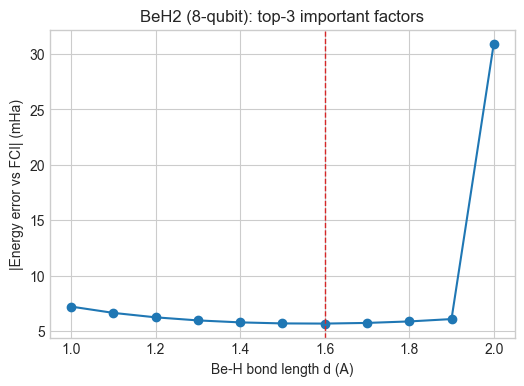

In [4]:
display(df)
display(scan_df)

ax = scan_df.plot(
    x="d_angstrom",
    y="abs_error_to_FCI_mHa",
    marker="o",
    legend=False,
    figsize=(6, 4),
)
ax.axvline(best_d, color="tab:red", linestyle="--", linewidth=1.0)
ax.set_ylabel("|Energy error vs FCI| (mHa)")
ax.set_xlabel("Be-H bond length d (A)")
ax.set_title("BeH2 (8-qubit): top-3 important factors")
plt.show()

## Notes

- This keeps the **top 3 total parameters** from both singles and doubles.
- Importance ranking is based on absolute MP2 initial amplitude.
- `active_space=(4, 4)` gives an 8-qubit BeH2 problem in STO-3G.
- The scan chooses `best_d` by minimizing `abs_error_to_FCI_mHa` over `d_grid`.
- Lower `error_to_FCI_mHa` means closer to the true ground-state energy.